In [1]:
# Version 1.0, January 17, 2026
# Press SHiFT + ENTER once to activate all definitions in this cell. They can then be accessed from each cell in this notebook.

#Define real and complex Ball fields
RDF=RealBallField(270)
CCF=ComplexBallField(270)

global half, frac32, frac52, tanh14 
half = CCF("0.5"); frac32 = CCF("1.5"); tanh14 = CCF("0.25").tanh()

#Pochhammer symbol
def PH(z, n):
    return (z + n).gamma() / (z).gamma()

#Hypergeometric functions
def hyp1F1(a1, b1, y):
    return  y.hypergeometric([a1],[b1])

def hyp2F1(a1, a2, b1, y):
    return  CCF(y).hypergeometric([a1, a2],[b1])

def hyp3F2(a1, a2, a3, b1, b2, y):
    return  CCF(y).hypergeometric([a1, a2, a3],[b1, b2])

def hyp4F3(a1, a2, a3, a4, b1, b2, b3, y):
    return  CCF(y).hypergeometric([a1, a2, a3, a4],[b1, b2, b3])

def F3(a1, a2, b1, b2, g, x, y):
    sum = 0
    for s in range(60):
        sum = sum + PH(a1,s) * PH(b1,s) / (PH(g,s) * (s+1).gamma()) * x.pow(s) * hyp2F1(a2, b2, g + s, y)
    return sum

def C(n, k, a, b):
    f1 = PH(n + a,k) * PH(n + a + half,k) * PH(n + a + b,k)  / ((k + 1). gamma() * PH(n + half,k) * PH(a + b + 2*n - half +k,k))
    f2 = hyp4F3(-k, 2*n + k + a + b - half, n + a + b, n + 2*a, 2*n + 2*a + 2*b, n + a + half, n + a, 1)
    return f1 * f2 
    
#Orthogonal polynomials

# Meixner-Pollaczek
def MPPoly(t, n, l): 
    f1  =  CCF(l,0) + CCF(0,1) * t
    return CCF(0,1).pow(n) * PH(2*l,n) / (n+1).gamma() * hyp2F1(-n, f1, 2*l, 2)

def MPM(n, l): # M
    return  2 * CCF(pi()) * (n + 2*l).gamma()  / (CCF(2).pow(2*l) * (n+1).gamma())

def MPw(x, l): # Weight
    f1  =  CCF(l,0) + CCF(0,1) * x; f2  =  CCF(l,0) + CCF(0,-1) * x
    return f1.gamma() * f2.gamma()

# Continuous Hahn
def CHPoly(t, n, a, b):
    f1  =  CCF(a,0) + CCF(0,1) * t
    return CCF(0,1).pow(n) * PH(2*a,n) * PH(a + b,n) / (n + 1).gamma() * hyp3F2(-n, n + 2*a +2*b -1, f1, a + b, 2*a, 1)

def CHM(n, a, b): # M
    return  2 * CCF(pi()) * (n + 2*a).gamma()  * ((n + a + b).gamma()).pow(2) * (n + 2*b).gamma() / ((n + n + 2*a + 2*b - 1) * (n + 2*a + 2*b - 1).gamma() * (n+1).gamma())
    
def CHw(x, a, b): # Weight
    f1  =  CCF(a,0) + CCF(0,1) * x; f2  =  CCF(b,0) + CCF(0,1) * x; f3  =  CCF(a,0) + CCF(0,-1) * x; f4  =  CCF(b,0) + CCF(0,-1) * x
    return f1.gamma()  * f2.gamma() * f3.gamma() * f4.gamma()

# Continuous Dual Hahn
def CDHPoly(t, n, a, b, c):
    f1  =  CCF(a,0) + CCF(0,1) * t; f2 = CCF(a,0) - CCF(0,1) * t
    return PH(a + b,n) * PH(a + c,n) * hyp3F2(-n, f1, f2, a + b, a + c, 1)

def CDHM(n, a, b, c): # M
    return  2 * CCF(pi()) * (n+1).gamma() * (n + a + b).gamma()  * (n + a + c).gamma() * (n + b + c).gamma()

def CDHw(x, a, b, c): # Weight
    f1  =  CCF(a,0) + CCF(0,1) * x; f2  =  CCF(b,0) + CCF(0,1) * x; f3  =  CCF(c,0) + CCF(0,1) * x; f4 = 2 * CCF(0,1) * x
    fac = f1.gamma()  * f2.gamma() * f3.gamma() / f4.gamma()
    return CCF(fac.abs()).pow(2)

# Wilson
def WilPoly(t, n, a, b):
    f1  =  CCF(a,0) + CCF(0,1) * t; f2 = CCF(a,0) - CCF(0,1) * t
    return PH(a + b,n) * PH(2*a,n) * PH(a + b,n) * hyp4F3(-n, n + 2*a + 2*b - 1, f1, f2, a + b, 2*a, a + b, 1)

def WilM(n, a, b): # M
    return  2 * CCF(pi()) * PH(n + 2*a + 2*b - 1,n) * (n + 1).gamma() * ((n + a + b).gamma()).pow(4) * (n + 2*a).gamma() * (n + 2*b).gamma() / ((2*n + 2*a + 2*b).gamma())

def Wilw(x, a, b): # Weight
    f1  =  CCF(a,0) + CCF(0,1) * x; f2  =  CCF(b,0) + CCF(0,1) * x; f3 = 2 * CCF(0,1) * x
    fac = (f1.gamma()).pow(2) * (f2.gamma()).pow(2) / f3.gamma()
    return CCF(fac.abs()).pow(2)

#Functions to be expanded
def Xi(t):
    f=CCF("0.5",0)+CCF(0,1) * t
    return f / 2 * (f-1) * CCF(pi).pow(-f/2)  *(f/2).gamma() * f.zeta()

def Xii(t):
    return 2 * (t / 2).sin() / t

def Phi(x):
    xa = x.abs()
    termexp2x=-1*RDF(pi)*RDF(2*xa).exp(); termexp5x= 6*RDF(pi)*RDF(5*xa/2).exp(); termexp9x= 4*RDF(pi)*RDF(pi)*RDF(9*xa/2).exp()
    sum=(RDF(0))
    for n in range(12):
        summand =  ((n+1)^4*termexp9x-(n+1)^2*termexp5x)*((n+1)^2*termexp2x).exp()   
        sum = sum + summand
    return sum

print("Done!")

Done!


In [2]:
print("Compare the target coefficients with the simplified versions for each family: \n")

def MPCoeffXiT(n, l):
    res =  2 * CCF(-1).pow(n) / MPM(2*n, l) * CCF.integral(lambda x, _: Xi(x) * MPPoly(x, 2*n, l) * MPw(x, l), CCF("10e-30"), CCF("24"))
    return res

def MPCoeffXiS(n, l):
    res =  4 * CCF.integral(lambda w, _: Phi(2 * w.arctanh()) * w.pow(2*n) * (1-w^2).pow(l-1), CCF("10e-30"), CCF("0.999"))
    return res

print("MPXi   coeff target: %1.20e" % real_part(MPCoeffXiT(3,2)))
print("MPXi   coeff simpl.: %1.20e" % real_part(MPCoeffXiS(3,2)))

def MPCoeffXiiT(n, l):
    res =  2 * CCF(-1).pow(n) / MPM(2*n, l) * CCF.integral(lambda x, _: Xii(x) * MPPoly(x, 2*n, l) * MPw(x, l), CCF("10e-30"), CCF("24"))
    return res

def MPCoeffXiiS(n, l):
    res =  4 * tanh14.pow(2*n + 1) / (2*n + 1) * hyp2F1(1 - l,n + half, n + frac32, tanh14.pow(2))
    return res

print("MPXii  coeff target: %1.20e" % real_part(MPCoeffXiiT(3,2)))
print("MPXii  coeff simpl.: %1.20e \n" % real_part(MPCoeffXiiS(3,2)))

def CHCoeffXiT(n, a, b):
    res =  2 * CCF(-1).pow(n) / CHM(2*n, a, b) * CCF.integral(lambda x, _: Xi(x) * CHPoly(x, 2*n, a, b) * CHw(x, a, b), CCF("10e-30"), CCF("12"))
    return res

def CHCoeffXiS(n, a, b):
    pre = CCF(2).pow(2*n+2) / PH(2*n + 2*a + 2*b -1, 2*n)
    res =  pre * CCF.integral(lambda w, _: Phi(2 * w.arctanh()) * w.pow(2*n) * (1 - w^2).pow(a - 1) * hyp2F1(a + n,a + n + half, a + b + 2*n + half,w^2), CCF("10e-30"), CCF("0.999"))
    return res

print("CHXi   coeff target: %1.20e" % real_part(CHCoeffXiT(3,CCF(2),CCF(1))))
print("CHXi   coeff simpl.: %1.20e" % real_part(CHCoeffXiS(3,CCF(2),CCF(1))))

def CHCoeffXiiT(n, a, b):
    res =  2 * CCF(-1).pow(n) / CHM(2*n, a, b) * CCF.integral(lambda x, _: Xii(x) * CHPoly(x, 2*n, a, b) * CHw(x, a, b), CCF("10e-90"), CCF("30"))
    return res

def CHCoeffXiiS(n, a, b):
    pre = CCF(2).pow(2*n + 2) / PH(2*n + 2*a + 2*b -1, 2*n)
    res =  pre * CCF.integral(lambda w, _: w.pow(2*n) * (1 - w.pow(2)).pow(a - 1) * hyp2F1(a + n,a + n + half, a + b + 2*n + half,w.pow(2)), CCF("10e-90"), tanh14)
    return res

print("CHXii  coeff target: %1.20e" % real_part(CHCoeffXiiT(3,CCF(2),CCF(1))))
print("CHXii  coeff simpl.: %1.20e \n" % real_part(CHCoeffXiiS(3,CCF(2),CCF(1))))

def CDHCoeffXiT(n, a, b, c):
    res =  1 / CDHM(n, a, b, c) * CCF.integral(lambda x, _: Xi(x) * CDHPoly(x, n, a, b, c) * CDHw(x, a, b, c), CCF("10e-30"), CCF("24"))
    return res

def CDHCoeffXiS(n, a, b, c):
    pre = CCF(2).pow(2*n + 2) / (2*n + 1).gamma()
    res =  pre * CCF.integral(lambda w, _: Phi(2 * w.arctanh()) * w.pow(2*n) * (1 - w^2).pow(a + b - 1) * F3(n + a + b,-b,half - c, -a, n + half, w^2, w^2/(w^2 - 1)), CCF("10e-30"), CCF("0.99"))
    return res

print("CDHXi  coeff target: %1.20e" % real_part(CDHCoeffXiT(3,CCF(2.2),CCF(1.1), CCF(4.1))))
print("CDHXi  coeff simpl.: %1.20e" % real_part(CDHCoeffXiS(3,CCF(2.2),CCF(1.1), CCF(4.1))))

def CDHCoeffXiiT(n, a, b, c):
    res =  1 / CDHM(n, a, b, c) * CCF.integral(lambda x, _: Xii(x) * CDHPoly(x, n, a, b, c) * CDHw(x, a, b, c), CCF("10e-30"), CCF("50"))
    return res

def CDHCoeffXiiS(n, a, b, c):
    pre = CCF(2).pow(2*n + 2) / (2*n + 1).gamma()
    res =  pre * CCF.integral(lambda w, _: w.pow(2*n) * (1 - w.pow(2)).pow(a + b - 1) * F3(n + a + b, -b, half - c, -a, n + half, w^2, w^2/(w^2 - 1)), CCF("10e-30"), tanh14)
    return res

print("CDHXii coeff target: %1.20e" % real_part(CDHCoeffXiiT(3,CCF(2.2),CCF(1.1), CCF(4.1))))
print("CDHXii coeff simpl.: %1.20e \n" % real_part(CDHCoeffXiiS(3,CCF(2.2),CCF(1.1), CCF(4.1))))

def WilCoeffXiT(n, a, b):
    res =  1 / WilM(n, a, b) * CCF.integral(lambda x, _: Xi(x) * WilPoly(x, n, a, b) * Wilw(x, a, b), CCF("10e-30"), CCF("24"))
    return res

def WilCoeffXiS(n, a, b):
    pre = CCF(2).pow(2*n + 2) / ((2*n + 1).gamma() * PH(n + 2*a + 2*b - 1,n))
    sum = 0
    for k in range(30):
        integ = CCF.integral(lambda w, _: Phi(2 * w.arctanh()) * w.pow(2*n + 2*k) * (1 - w^2).pow(a - 1) * hyp2F1(a + n + k, a + n + k + half, 2*n + 2*k + a + b + half, w.pow(2)), CCF("10e-30"), CCF("0.8"))
        sum = sum + C(n, k, a, b) * integ
    return  pre * sum

print("WilXi  coeff target: %1.20e" % real_part(WilCoeffXiT(3,CCF(2.2),CCF(1.1)).mid()))
print("WilXi  coeff simpl.: %1.20e" % real_part(WilCoeffXiS(3,CCF(2.2),CCF(1.1)).mid()))

def WilCoeffXiiT(n, a, b):
    return 1 / WilM(n, a, b) * CCF.integral(lambda x, _: Xii(x) * WilPoly(x, n, a, b) * Wilw(x, a, b), CCF("10e-30"), CCF("15"))

def WilCoeffXiiS(n, a, b):
    pre = CCF(2).pow(2*n + 2) / ((2*n + 1).gamma() * PH(n + 2*a + 2*b - 1,n))
    sum = 0
    for k in range(50):
        integ = CCF.integral(lambda w, _: w.pow(2*n + 2*k) * (1 - w.pow(2)).pow(a - 1) * hyp2F1(a + n + k, a + n + k + half, 2*n + 2*k + a + b + half, w.pow(2)), CCF("10e-30"), tanh14)
        sum = sum + C(n, k, a, b) * integ
    return  pre * sum

print("WilXii coeff target: %1.20e" % real_part(WilCoeffXiiT(3,CCF(2.2),CCF(1.1)).mid()))
print("WilXii coeff simpl.: %1.20e" % real_part(WilCoeffXiiS(3,CCF(2.2),CCF(1.1)).mid()))

Compare the target coefficients with the simplified versions for each family: 

MPXi   coeff target: 7.24312210286657322819e-06
MPXi   coeff simpl.: 7.24312210286657322819e-06
MPXii  coeff target: 2.87981867272053068815e-05
MPXii  coeff simpl.: 2.87981867272053068815e-05 

CHXi   coeff target: 9.65944270927537160324e-11
CHXi   coeff simpl.: 9.65944270927537160324e-11
CHXii  coeff target: 3.66965012247527455509e-10
CHXii  coeff simpl.: 3.66965012247527455509e-10 

CDHXi  coeff target: 3.80560269953720913419e-07
CDHXi  coeff simpl.: 3.80560269953720913419e-07
CDHXii coeff target: 1.69176045776639823592e-06
CDHXii coeff simpl.: 1.69176045776639823592e-06 

WilXi  coeff target: 8.12143263628933055431e-10
WilXi  coeff simpl.: 8.12143263628933055431e-10
WilXii coeff target: 3.15451149954298122277e-09
WilXii coeff simpl.: 3.15451149954298122277e-09


In [6]:
print("Compare the flows of the simplified coefficients with Xi(t) and Xii(t) \n")

def MPFlow(t,l,r):
    sumi = 0; sumii = 0
    for n in range(21):
        sumi = sumi + CCF(-1).pow(n) * MPPoly(t,2*n,l) * MPCoeffXiS(n,l) * r.pow(2*n)
        sumii = sumii + CCF(-1).pow(n) * MPPoly(t,2*n,l) * MPCoeffXiiS(n,l) * r.pow(2*n)
    return sumi, sumii

print("MPFlow(r=1) : %1.20e" % real_part(MPFlow(CCF(2),CCF(6),CCF(1))[0]))
print("Xi-function : %1.20e" % real_part(Xi(CCF(2))))

print("MPFlow(r=1) : %1.20e" % real_part(MPFlow(CCF(2),CCF(6),CCF(1))[1]))
print("Xii-function: %1.20e \n" % real_part(Xii(CCF(2))))

def CHFlow(t, a, b, r):
    sumi = 0; sumii = 0
    for n in range(21):
        sumi = sumi + CCF(-1).pow(n) * CHPoly(t,2*n,a,b) * CHCoeffXiS(n,a,b) * r.pow(2*n)
        sumii = sumii + CCF(-1).pow(n) * CHPoly(t,2*n,a,b) * CHCoeffXiiS(n,a,b) * r.pow(2*n)
    return sumi, sumii

print("CHFlow(r=1) : %1.20e" % real_part(CHFlow(CCF(2),CCF(6),CCF(3),CCF(1))[0]))
print("Xi-function : %1.20e" % real_part(Xi(CCF(2))))

print("CHFlow(r=1) : %1.20e" % real_part(CHFlow(CCF(2),CCF(6),CCF(3),CCF(1))[1]))
print("Xii-function: %1.20e \n" % real_part(Xii(CCF(2))))

def CDHFlow(t, a, b, c, r):
    sumi = 0; sumii = 0
    for n in range(6):
        sumi = sumi + CDHPoly(t,n,a,b,c) * CDHCoeffXiS(n,a,b,c) * r.pow(n)
        sumii = sumii + CDHPoly(t,n,a,b,c) * CDHCoeffXiiS(n,a,b,c) * r.pow(n)
    return sumi, sumii

print("CDHFlow(r=1): %1.20e" % real_part(CDHFlow(CCF(2),CCF(6),CCF(3),CCF(4),CCF(1))[0]))
print("Xi-function : %1.20e" % real_part(Xi(CCF(2))))

print("CDHFlow(r=1): %1.20e" % real_part(CDHFlow(CCF(2),CCF(6),CCF(3),CCF(4),CCF(1))[1]))
print("Xii-function: %1.20e \n" % real_part(Xii(CCF(2))))

def WilFlow(t, a, b, r):
    sumi = 0; sumii = 0
    for n in range(18):
        sumi = sumi + WilPoly(t,n,a,b) * WilCoeffXiS(n,a,b) * r.pow(n*(n + 2*a + 2*b -1))
        sumii = sumii + WilPoly(t,n,a,b) * WilCoeffXiiS(n,a,b) * r.pow(n)
    return sumi, sumii

print("WilFlow(r=1): %1.20e" % real_part(WilFlow(CCF(2),CCF(6),CCF(3),CCF(1))[0]))
print("Xi-function : %1.20e" % real_part(Xi(CCF(2))))

print("WilFlow(r=1): %1.20e" % real_part(WilFlow(CCF(2),CCF(6),CCF(3),CCF(1))[1]))
print("Xii-function: %1.20e \n" % real_part(Xii(CCF(2))))

Compare the flows of the simplified coefficients with Xi(t) and Xii(t) 

MPFlow(r=1) : 4.53099858312936087934e-01
Xi-function : 4.53099858312936087934e-01
MPFlow(r=1) : 8.41470984807896504876e-01
Xii-function: 8.41470984807896504876e-01 

CHFlow(r=1) : 4.53099858312936087934e-01
Xi-function : 4.53099858312936087934e-01
CHFlow(r=1) : 8.41470984807896504876e-01
Xii-function: 8.41470984807896504876e-01 

CDHFlow(r=1): 4.50640849886253747059e-01
Xi-function : 4.53099858312936087934e-01
CDHFlow(r=1): 8.35836808065787861821e-01
Xii-function: 8.41470984807896504876e-01 

WilFlow(r=1): 4.53099858312936087934e-01
Xi-function : 4.53099858312936087934e-01
WilFlow(r=1): 8.41470984807896504876e-01
Xii-function: 8.41470984807896504876e-01 



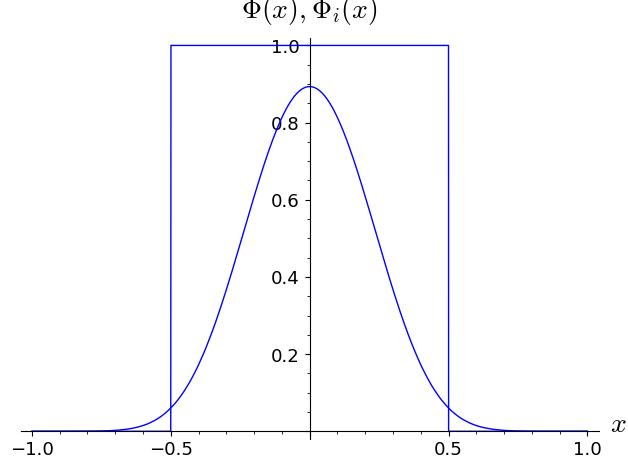

In [504]:
var('x')
def Ind(x):
    res = 1
    if x >= 1/2 or x <= -1/2:
        res = 0    
    return res

a=plot(lambda x: real_part(Phi(CCF(str(x)))),(x,-1,1), color='blue',fontsize=13,axes_labels=['$x$','$\Phi(x), \Phi_i(x)$'])
b=plot(lambda x: real_part(Ind(x)),(x,-1,1), color='blue')
show(a + b,aspect_ratio='automatic')

In [12]:
CDHCoeffXiiT(CCF("6"),CCF("2"),CCF("1"),CCF("0.5"))

KeyboardInterrupt: 

In [ ]:
CDHFlow(CCF(2),CCF(1),CCF(1),CCF("0.5"),CCF(1))[1]

In [15]:
def CDHFlow(t, a, b, c, r):
    sumi = 0; sumii = 0
    for n in range(8):
        sumii = sumii + CDHPoly(t,n,a,b,c) * CDHCoeffXiiS(n,a,b,c) * r.pow(n)
    return sumii

CDHFlow(CCF(2),CCF(2),CCF(1),CCF("3"),CCF("0.9"))

[0.816921583530774691480885707858537322441875764860289192478354822316977394833427 +/- 4.37e-79]

In [22]:
def CDHCoeffXiT(n, a, b, c):
    res =  1 / CDHM(n, a, b, c) * CCF.integral(lambda x, _: Xi(x) * CDHPoly(x, n, a, b, c) * CDHw(x, a, b, c), CCF("10e-30"), CCF("24"))
    return res

CDHCoeffXiT(4, 2, 1, CCF("0.5"))

[2.477811730617413448176124912804694175424598243099724140445032717999462894e-9 +/- 4.28e-82] + [+/- 7.38e-83]*I

In [19]:
2*9.01652516614904081486030370739972066662551419399244684

18.033050332298081629720607414799441333251028387984894

In [21]:
2*2.259324566981143175615066553133598788209888619425

4.51864913396228635123013310626719757641977723885

In [59]:
def CHCoeffXiiS(n, a, b):
    pre = CCF(2).pow(2*n + 2) / PH(2*n + 2*a + 2*b -1, 2*n)
    res =  pre * CCF.integral(lambda w, _: w.pow(2*n) * (1 - w.pow(2)).pow(a - 1) * hyp2F1(a + n,a + n + half, a + b + 2*n + half,w.pow(2)), CCF("10e-90"), tanh14)
    return res

CHCoeffXiiS(3, CCF("0.5"),1)

[1.742192049585105658346916187216024833577654286876097971521700765945792166034803e-9 +/- 5.44e-88]

In [58]:
def CHCoeffXiiS(n, a, b):
    pre = CCF(2).pow(2*n + 2) / PH(2*n + 2*a + 2*b -1, 2*n)
    res =  pre * CCF.integral(lambda w, _: w.pow(2*n) * (1 - w.pow(2)).pow(a - 1) * hyp2F1(a + n,a + n + half, a + b + 2*n + half,w.pow(2)), CCF("10e-90"), tanh14)
    return res

CHCoeffXiiS(3, 1,CCF("0.5"))

[1.548844507998695684429169758154104932210403851531122233216635865906534980448294e-9 +/- 7.55e-88]

In [6]:
def CHFlow(t, a, b, r):
    sumii = 0
    for n in range(21):
        sumii = sumii + CCF(-1).pow(n) * CHPoly(t,2*n,a,b) * CHCoeffXiS(n,a,b) * r.pow(2*n)
    return sumii

CHFlow(3, CCF("0.5"),1, CCF("0.1"))

[0.4946876697572877694494106258282665526115527832252734441608952388245871944926717 +/- 7.93e-80] + [+/- 1.79e-84]*I

In [5]:
def CHFlow(t, a, b, r):
    sumii = 0
    for n in range(21):
        sumii = sumii + CCF(-1).pow(n) * CHPoly(t,2*n,a,b) * CHCoeffXiiS(n,a,b) * r.pow(2*n)
    return sumii

CHFlow(7+I, 1, CCF("0.5"), CCF("0.1"))

[0.9752879678109889594292495791172181821441346512889691223703913549389160141483531 +/- 6.86e-80] + [-0.005676165822991439019608334854014960674926948033520312242302742333068851569313002 +/- 7.78e-82]*I

In [51]:
def WilCoeffXiiS(n, a, b):
    pre = CCF(2).pow(2*n + 2) / ((2*n + 1).gamma() * PH(n + 2*a + 2*b - 1,n))
    sum = 0
    for k in range(50):
        integ = CCF.integral(lambda w, _: w.pow(2*n + 2*k) * (1 - w.pow(2)).pow(a - 1) * hyp2F1(a + n + k, a + n + k + half, 2*n + 2*k + a + b + half, w.pow(2)), CCF("10e-50"), tanh14)
        sum = sum + C(n, k, a, b) * integ
    return  pre * sum

WilCoeffXiiS(0, CCF("0.5"), 1)

[0.9794403848550007989826202728491930600534995112134709484335042567437160890369758 +/- 7.85e-80]

In [18]:
def WilFlow(t, a, b, r):
    sumii = 0
    for n in range(50):
        sumii = sumii + WilPoly(t,n,a,b) * WilCoeffXiiS(n,a,b) * r.pow(n)
    return sumii

WilFlow(CCF(2,1), CCF("0.5"), CCF(1), CCF("0.63"))

[0.913126721008842251160301642338893224309568645484795887814020567745887673590947 +/- 1.39e-79] + [-0.0989399250500859380346289186070087428377729586223182836661091863926699418449581 +/- 5.36e-80]*I

In [16]:
def WilCoeffXiS(n, a, b):
    pre = CCF(2).pow(2*n + 2) / ((2*n + 1).gamma() * PH(n + 2*a + 2*b - 1,n))
    sum = 0
    for k in range(12):
        integ = CCF.integral(lambda w, _: Phi(2 * w.arctanh()) * w.pow(2*n + 2*k) * (1 - w^2).pow(a - 1) * hyp2F1(a + n + k, a + n + k + half, 2*n + 2*k + a + b + half, w.pow(2)), CCF("10e-30"), CCF("0.8"))
        sum = sum + C(n, k, a, b) * integ
    return  pre * sum

WilCoeffXiS(2, CCF("0.5"), 1)

[5.89069321732140782061734308544758966650718207299117504133373936628960906409208e-6 +/- 3.65e-84]

In [5]:
def MPFlow(t,l,r):
    sumii = 0
    for n in range(21):
        sumii = sumii + CCF(-1).pow(n) * MPPoly(t,2*n,l) * MPCoeffXiiS(n,l) * r.pow(2*n)
    return sumii

MPFlow(CCF(2,1),3,CCF("0.6"))

[0.9197395108633506553489484276730419449038106615878431589767840793532296628596688 +/- 4.84e-80] + [-0.05356034819882385330935697743959998963959643036898937704906274706822288363497888 +/- 3.12e-81]*I

In [2]:
import numpy as np
from scipy.integrate import quad
from scipy.special import genlaguerre, hyp1f1, iv, gamma
from math import factorial

# Parameters for the numerical test
ALPHA = -0.5  # Must be >= -0.5 for stable convergence in standard contexts
T = 1.0       # Arbitrary parameter t
R = 0.5       # Must be < 1 for convergence
N_TERMS = 10  # Number of terms for the LHS summation
LIMIT = 5.0   # Integration limits (Phi(x) decays double-exponentially, so 5 is practically infinity)

def riemann_kernel(x):
    """
    The standard even Riemann kernel Phi(x) for the Fourier cosine transform of Xi(t).
    Due to its symmetric nature, it is often defined via the Jacobi theta function.
    Here we use the first few terms of the series definition, which converges extremely rapidly.
    """
    x = np.abs(x) # Ensure it acts as an even function
    u = np.exp(2 * x)
    
    # We only need the first few terms (n=1, 2) because exp(-pi * n^2 * u^2) decays instantly
    phi_val = 0.0
    for n in range(1, 4):
        term1 = 4 * np.pi**2 * n**4 * u**(9/2)
        term2 = 6 * np.pi * n**2 * u**(5/2)
        exponential = np.exp(-np.pi * n**2 * u**2)
        phi_val += (term1 - term2) * exponential
    return phi_val

# --- LEFT HAND SIDE (LHS) ---

def lhs_integrand(x, n, alpha, t, r):
    # n! / (2n)!
    coef1 = factorial(n) / factorial(2 * n)
    # L_n^alpha(t^2)
    laguerre_poly = genlaguerre(n, alpha)
    L_n = laguerre_poly(t**2)
    # x^(2n) * r^(2n)
    power_term = (x * r)**(2 * n)
    # 1F1(n+alpha+1; n+0.5; -x^2/4)
    hypergeom = hyp1f1(n + alpha + 1, n + 0.5, -x**2 / 4.0)
    
    return riemann_kernel(x) * coef1 * L_n * power_term * hypergeom

def compute_lhs(alpha, t, r, n_terms):
    total_sum = 0.0
    for n in range(n_terms):
        # Integrate each term in the sum
        integral_val, error = quad(lhs_integrand, -LIMIT, LIMIT, args=(n, alpha, t, r))
        total_sum += integral_val
        print(f"LHS Term n={n}: {integral_val}")
    return total_sum

# --- RIGHT HAND SIDE (RHS) ---

def rhs_integrand(x, alpha, t, r):
    # Normalization factor
    norm = 1.0 / ((1 - r**2)**(alpha + 1))
    
    # Exponential factor
    exp_factor = np.exp((x**2 / 4.0) - (r**2 * (x**2 + t**2) / (1 - r**2)))
    
    # Bessel argument
    bessel_arg = (t * x * r) / (1 - r**2)
    
    # Handle the x=0 singularity for the term (bessel_arg)^(-alpha) * I_alpha(bessel_arg)
    if x == 0:
        # Limit as z -> 0 of z^(-alpha) I_alpha(z) is 1 / (2^alpha * Gamma(alpha + 1))
        bessel_term = 1.0 / (2**alpha * gamma(alpha + 1))
    else:
        bessel_term = (bessel_arg)**(-alpha) * iv(alpha, bessel_arg)
        
    return riemann_kernel(x) * norm * exp_factor * bessel_term

def compute_rhs(alpha, t, r):
    integral_val, error = quad(rhs_integrand, -LIMIT, LIMIT, args=(alpha, t, r), points=[0])
    return integral_val

# --- EXECUTION ---

if __name__ == "__main__":
    print("Computing LHS (Truncated Series of Integrals)...")
    lhs_val = compute_lhs(ALPHA, T, R, N_TERMS)
    
    print("\nComputing RHS (Single Integral)...")
    rhs_val = compute_rhs(ALPHA, T, R)
    
    print("\n--- RESULTS ---")
    print(f"LHS (Sum of {N_TERMS} terms): {lhs_val:.8e}")
    print(f"RHS (Single integral):      {rhs_val:.8e}")
    print(f"Difference:                 {abs(lhs_val - rhs_val):.8e}")

Computing LHS (Truncated Series of Integrals)...
LHS Term n=0: 0.24784539709923584
LHS Term n=1: -0.00017803070524805706
LHS Term n=2: -2.9761807044078374e-07
LHS Term n=3: -2.5916386811881715e-10
LHS Term n=4: -1.8945037966445192e-13
LHS Term n=5: -6.364480610167197e-17
LHS Term n=6: 1.116462367220877e-19
LHS Term n=7: 2.6480853544462115e-22
LHS Term n=8: 3.3010660814443154e-25
LHS Term n=9: 3.0179057636967127e-28

Computing RHS (Single Integral)...

--- RESULTS ---
LHS (Sum of 10 terms): 2.47667069e-1
RHS (Single integral):      nan
Difference:                 NaN
